# Notebook 3 — µP Scaling and Scaling-Law Extrapolation

Project: **SVG-GPT: Scaling Transformer Language Models for Vector Graphics**

This notebook completes **Part 3** of the project.

It does the following:

1. Reparameterizes the Transformer using **µP**.
2. Runs a learning-rate sweep on the smallest µP model.
3. Transfers the best µP learning rate to larger models without retuning.
4. Trains all model sizes for 1 epoch.
5. Compares standard parameterization from Notebook 2 vs µP.
6. Fits power laws to both curves.
7. Predicts the validation loss for a model with **10× more parameters** than the largest trained model.

Notebook 2 found that fixed standard-parameterization LR worked well up to Large but failed badly for XL. Part 3 tests whether µP gives better learning-rate transfer to wider models.

In [1]:
# Check GPU availability
import torch

print("PyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
else:
    print("WARNING: No GPU detected. Go to Runtime -> Change runtime type -> GPU.")

PyTorch version: 2.10.0+cu128
CUDA available: True
GPU: NVIDIA A100-SXM4-80GB


## 1. Mount Google Drive

This notebook reads:

```text
MyDrive/
  svg_gpt_scaling/
    notebook1_preprocessing/
    notebook2_standard_scaling/
```

and writes:

```text
MyDrive/
  svg_gpt_scaling/
    notebook3_mup_scaling/
      checkpoints/
      logs/
      results/
      plots/
```

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
from pathlib import Path

PROJECT_ROOT = Path("/content/drive/MyDrive/svg_gpt_scaling")

NOTEBOOK1_DIR = PROJECT_ROOT / "notebook1_preprocessing"
NOTEBOOK2_DIR = PROJECT_ROOT / "notebook2_standard_scaling"
NOTEBOOK3_DIR = PROJECT_ROOT / "notebook3_mup_scaling"

CHECKPOINTS_DIR = NOTEBOOK3_DIR / "checkpoints"
LOGS_DIR = NOTEBOOK3_DIR / "logs"
RESULTS_DIR = NOTEBOOK3_DIR / "results"
PLOTS_DIR = NOTEBOOK3_DIR / "plots"

for d in [CHECKPOINTS_DIR, LOGS_DIR, RESULTS_DIR, PLOTS_DIR]:
    d.mkdir(parents=True, exist_ok=True)

print("Project root:", PROJECT_ROOT)
print("Notebook 1 folder:", NOTEBOOK1_DIR)
print("Notebook 2 folder:", NOTEBOOK2_DIR)
print("Notebook 3 folder:", NOTEBOOK3_DIR)
print("Folders ready.")

Project root: /content/drive/MyDrive/svg_gpt_scaling
Notebook 1 folder: /content/drive/MyDrive/svg_gpt_scaling/notebook1_preprocessing
Notebook 2 folder: /content/drive/MyDrive/svg_gpt_scaling/notebook2_standard_scaling
Notebook 3 folder: /content/drive/MyDrive/svg_gpt_scaling/notebook3_mup_scaling
Folders ready.


## 2. Install and Import Dependencies

I have installed `mup` for Maximal Update Parameterization.

The µP package recommends replacing the output layer with `MuReadout`, setting base shapes using `set_base_shapes`, using µP optimizers, and changing Transformer attention scaling from `1/sqrt(d)` to `1/d`-style scaling.

In [4]:
!pip -q install tokenizers pandas matplotlib scipy tqdm numpy mup

  Preparing metadata (setup.py) ... done


In [5]:
import os
import json
import math
import time
import random
import gc
from dataclasses import dataclass, asdict
from pathlib import Path
from typing import Dict, Optional

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.nn import functional as F

from tokenizers import Tokenizer
from scipy.optimize import curve_fit

import mup
from mup import MuReadout, MuAdamW, set_base_shapes

print("Imports complete.")
print("mup imported successfully.")

Imports complete.
mup imported successfully.


## 3. Main Configuration

This matches Notebook 2 wherever possible:

- same tokenizer
- same `.bin` tokenized data
- same block size
- same micro-batch size
- same gradient accumulation
- same tokens/update
- same one-epoch comparison protocol

In [6]:
SANITY_MODE = False  # First run with True for debugging. Then switch to False.

RANDOM_SEED = 42

VOCAB_SIZE = 4096
BLOCK_SIZE = 512
DTYPE = "bfloat16" if torch.cuda.is_available() and torch.cuda.is_bf16_supported() else "float16"

MICRO_BATCH_SIZE = 16
GRAD_ACCUM_STEPS = 4

EVAL_INTERVAL = 500
EVAL_ITERS = 100
LOG_INTERVAL = 50

WARMUP_FRACTION = 0.03
MIN_LR_RATIO = 0.10

WEIGHT_DECAY = 0.1
BETA1 = 0.9
BETA2 = 0.95
GRAD_CLIP = 1.0

MUP_LR_SWEEP_VALUES = [1e-4, 2e-4, 3e-4, 6e-4, 1e-3, 2e-3, 3e-3]

SANITY_MAX_STEPS = 30
SANITY_EVAL_ITERS = 10

LR_SWEEP_MAX_STEPS_REAL = 1000

RESUME_IF_CHECKPOINT_EXISTS = True
SAVE_EVERY_EVAL = True

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(RANDOM_SEED)

print("SANITY_MODE:", SANITY_MODE)
print("Device:", DEVICE)
print("dtype:", DTYPE)
print("Block size:", BLOCK_SIZE)
print("Micro batch size:", MICRO_BATCH_SIZE)
print("Gradient accumulation steps:", GRAD_ACCUM_STEPS)
print("Tokens per optimizer update:", MICRO_BATCH_SIZE * GRAD_ACCUM_STEPS * BLOCK_SIZE)

SANITY_MODE: False
Device: cuda
dtype: bfloat16
Block size: 512
Micro batch size: 16
Gradient accumulation steps: 4
Tokens per optimizer update: 32768


## 4. Load Tokenized Data from Notebook 1

This notebook uses the exact same data as Notebook 2.

In [7]:
preprocess_config_path = NOTEBOOK1_DIR / "preprocess_config_full.json"

if not preprocess_config_path.exists():
    raise FileNotFoundError(
        f"Could not find {preprocess_config_path}. "
        "Make sure Notebook 1 was completed successfully in full mode."
    )

with preprocess_config_path.open("r", encoding="utf-8") as f:
    preprocess_config = json.load(f)

tokenizer_path = Path(preprocess_config["tokenizer_path"])
train_bin_path = Path(preprocess_config["token_files"]["train"]["bin_path"])
val_bin_path = Path(preprocess_config["token_files"]["val"]["bin_path"])
test_bin_path = Path(preprocess_config["token_files"]["test"]["bin_path"])

for p in [tokenizer_path, train_bin_path, val_bin_path, test_bin_path]:
    if not p.exists():
        raise FileNotFoundError(f"Missing required file: {p}")

tokenizer = Tokenizer.from_file(str(tokenizer_path))

train_tokens = np.memmap(train_bin_path, dtype=np.uint16, mode="r")
val_tokens = np.memmap(val_bin_path, dtype=np.uint16, mode="r")
test_tokens = np.memmap(test_bin_path, dtype=np.uint16, mode="r")

print("Tokenizer vocab size:", tokenizer.get_vocab_size())
print(f"Train tokens: {len(train_tokens):,}")
print(f"Val tokens:   {len(val_tokens):,}")
print(f"Test tokens:  {len(test_tokens):,}")

tokens_per_step = MICRO_BATCH_SIZE * GRAD_ACCUM_STEPS * BLOCK_SIZE
steps_per_epoch = len(train_tokens) // tokens_per_step
print(f"Tokens per optimizer step: {tokens_per_step:,}")
print(f"Steps per real epoch: {steps_per_epoch:,}")

Tokenizer vocab size: 4096
Train tokens: 164,389,332
Val tokens:   1,657,304
Test tokens:  1,655,554
Tokens per optimizer step: 32,768
Steps per real epoch: 5,016


## 5. Batch Loader

Same language-modeling objective as Notebook 2.

In [8]:
def get_batch(split: str, batch_size: int = MICRO_BATCH_SIZE, block_size: int = BLOCK_SIZE):
    if split == "train":
        data = train_tokens
    elif split == "val":
        data = val_tokens
    elif split == "test":
        data = test_tokens
    else:
        raise ValueError(f"Unknown split: {split}")

    ix = torch.randint(len(data) - block_size - 1, (batch_size,))
    x = torch.stack([
        torch.from_numpy(np.array(data[i:i+block_size], dtype=np.int64))
        for i in ix
    ])
    y = torch.stack([
        torch.from_numpy(np.array(data[i+1:i+1+block_size], dtype=np.int64))
        for i in ix
    ])

    if DEVICE == "cuda":
        x = x.pin_memory().to(DEVICE, non_blocking=True)
        y = y.pin_memory().to(DEVICE, non_blocking=True)
    else:
        x = x.to(DEVICE)
        y = y.to(DEVICE)

    return x, y


xb, yb = get_batch("train")
print("x shape:", xb.shape)
print("y shape:", yb.shape)
print("min token:", xb.min().item(), "max token:", xb.max().item())

x shape: torch.Size([16, 512])
y shape: torch.Size([16, 512])
min token: 1 max token: 3846


## 6. Define µP GPT-Style Transformer

Differences from Notebook 2:

1. The output projection is `MuReadout`.
2. Input and output embeddings are **not tied** here to keep the µP implementation simpler.
3. Attention uses `8 / head_dim` scaling instead of standard `1 / sqrt(head_dim)` scaling.
4. We call `set_base_shapes(model, base_model, delta=delta_model)` before creating the optimizer.
5. We use `MuAdamW`.

Note: the project model family changes both width and depth. µP is mainly about width scaling. For practical compatibility, each target model gets a base/delta shape template with the same depth and number of heads as the target, while scaling the per-head width.

In [9]:
@dataclass
class MuGPTConfig:
    name: str
    vocab_size: int
    block_size: int
    n_layer: int
    n_head: int
    n_embd: int
    d_ff: int
    dropout: float = 0.0
    bias: bool = True


class MuCausalSelfAttention(nn.Module):
    def __init__(self, config: MuGPTConfig):
        super().__init__()
        assert config.n_embd % config.n_head == 0

        self.n_head = config.n_head
        self.n_embd = config.n_embd
        self.head_dim = config.n_embd // config.n_head
        self.dropout = config.dropout

        self.c_attn = nn.Linear(config.n_embd, 3 * config.n_embd, bias=config.bias)
        self.c_proj = nn.Linear(config.n_embd, config.n_embd, bias=config.bias)

        self.attn_dropout = nn.Dropout(config.dropout)
        self.resid_dropout = nn.Dropout(config.dropout)

        self.register_buffer(
            "causal_mask",
            torch.tril(torch.ones(config.block_size, config.block_size))
            .view(1, 1, config.block_size, config.block_size)
        )

    def forward(self, x):
        B, T, C = x.size()

        q, k, v = self.c_attn(x).split(self.n_embd, dim=2)

        k = k.view(B, T, self.n_head, self.head_dim).transpose(1, 2)
        q = q.view(B, T, self.n_head, self.head_dim).transpose(1, 2)
        v = v.view(B, T, self.n_head, self.head_dim).transpose(1, 2)

        # µP-style Transformer attention scaling.
        # The mup README recommends 1/d rather than 1/sqrt(d), commonly implemented as 8/d.
        att = (q @ k.transpose(-2, -1)) * (8.0 / self.head_dim)
        att = att.masked_fill(self.causal_mask[:, :, :T, :T] == 0, float("-inf"))
        att = F.softmax(att, dim=-1)
        att = self.attn_dropout(att)

        y = att @ v
        y = y.transpose(1, 2).contiguous().view(B, T, C)
        y = self.resid_dropout(self.c_proj(y))
        return y


class MuMLP(nn.Module):
    def __init__(self, config: MuGPTConfig):
        super().__init__()
        self.c_fc = nn.Linear(config.n_embd, config.d_ff, bias=config.bias)
        self.gelu = nn.GELU()
        self.c_proj = nn.Linear(config.d_ff, config.n_embd, bias=config.bias)
        self.dropout = nn.Dropout(config.dropout)

    def forward(self, x):
        x = self.c_fc(x)
        x = self.gelu(x)
        x = self.c_proj(x)
        x = self.dropout(x)
        return x


class MuBlock(nn.Module):
    def __init__(self, config: MuGPTConfig):
        super().__init__()
        self.ln_1 = nn.LayerNorm(config.n_embd, bias=config.bias)
        self.attn = MuCausalSelfAttention(config)
        self.ln_2 = nn.LayerNorm(config.n_embd, bias=config.bias)
        self.mlp = MuMLP(config)

    def forward(self, x):
        x = x + self.attn(self.ln_1(x))
        x = x + self.mlp(self.ln_2(x))
        return x


class MuGPT(nn.Module):
    def __init__(self, config: MuGPTConfig):
        super().__init__()
        self.config = config

        self.transformer = nn.ModuleDict(dict(
            wte = nn.Embedding(config.vocab_size, config.n_embd),
            wpe = nn.Embedding(config.block_size, config.n_embd),
            drop = nn.Dropout(config.dropout),
            h = nn.ModuleList([MuBlock(config) for _ in range(config.n_layer)]),
            ln_f = nn.LayerNorm(config.n_embd, bias=config.bias),
        ))

        self.lm_head = MuReadout(config.n_embd, config.vocab_size, bias=False)

        self.apply(self._init_weights)

        for pn, p in self.named_parameters():
            if pn.endswith("c_proj.weight"):
                torch.nn.init.normal_(p, mean=0.0, std=0.02 / math.sqrt(2 * config.n_layer))

        # Recommended for µP readout transient stability.
        if hasattr(self.lm_head, "weight"):
            torch.nn.init.zeros_(self.lm_head.weight)

        # Recommended for µP Transformer coord stability: zero-initialize query projection.
        for block in self.transformer.h:
            q_weight = block.attn.c_attn.weight[:config.n_embd]
            torch.nn.init.zeros_(q_weight)
            if block.attn.c_attn.bias is not None:
                q_bias = block.attn.c_attn.bias[:config.n_embd]
                torch.nn.init.zeros_(q_bias)

    def _init_weights(self, module):
        if isinstance(module, nn.Linear):
            torch.nn.init.normal_(module.weight, mean=0.0, std=0.02)
            if module.bias is not None:
                torch.nn.init.zeros_(module.bias)
        elif isinstance(module, nn.Embedding):
            torch.nn.init.normal_(module.weight, mean=0.0, std=0.02)

    def forward(self, idx, targets=None):
        B, T = idx.size()
        assert T <= self.config.block_size

        pos = torch.arange(0, T, dtype=torch.long, device=idx.device)

        tok_emb = self.transformer.wte(idx)
        pos_emb = self.transformer.wpe(pos)
        x = self.transformer.drop(tok_emb + pos_emb)

        for block in self.transformer.h:
            x = block(x)

        x = self.transformer.ln_f(x)
        logits = self.lm_head(x)

        loss = None
        if targets is not None:
            loss = F.cross_entropy(
                logits.view(-1, logits.size(-1)),
                targets.view(-1),
                ignore_index=-1,
            )

        return logits, loss


def count_parameters(model: nn.Module) -> int:
    return sum(p.numel() for p in model.parameters())


print("µP model classes defined.")

µP model classes defined.


## 7. Define the Same Five Model Sizes

Because the µP readout is not tied to the embedding, parameter counts are slightly different from Notebook 2. I have to report actual parameter counts.

For each target model, I create:

- a base model with head dimension 32,
- a delta model with head dimension 64,
- the target model with the desired head dimension.

The base and delta models are only used to extract µP shape information.

In [10]:
MUP_MODEL_CONFIGS = [
    MuGPTConfig("Tiny", VOCAB_SIZE, BLOCK_SIZE, 4, 4, 128, 512, 0.0),
    MuGPTConfig("Small", VOCAB_SIZE, BLOCK_SIZE, 6, 6, 192, 768, 0.0),
    MuGPTConfig("Medium", VOCAB_SIZE, BLOCK_SIZE, 6, 6, 384, 1536, 0.0),
    MuGPTConfig("Large", VOCAB_SIZE, BLOCK_SIZE, 10, 8, 512, 2048, 0.0),
    MuGPTConfig("XL", VOCAB_SIZE, BLOCK_SIZE, 12, 12, 768, 3072, 0.0),
]


def make_mup_base_delta_configs(target_cfg: MuGPTConfig):
    base_head_dim = 32
    delta_head_dim = 64

    base_embd = target_cfg.n_head * base_head_dim
    delta_embd = target_cfg.n_head * delta_head_dim

    base_cfg = MuGPTConfig(
        name=target_cfg.name + "_base",
        vocab_size=target_cfg.vocab_size,
        block_size=target_cfg.block_size,
        n_layer=target_cfg.n_layer,
        n_head=target_cfg.n_head,
        n_embd=base_embd,
        d_ff=4 * base_embd,
        dropout=target_cfg.dropout,
        bias=target_cfg.bias,
    )

    delta_cfg = MuGPTConfig(
        name=target_cfg.name + "_delta",
        vocab_size=target_cfg.vocab_size,
        block_size=target_cfg.block_size,
        n_layer=target_cfg.n_layer,
        n_head=target_cfg.n_head,
        n_embd=delta_embd,
        d_ff=4 * delta_embd,
        dropout=target_cfg.dropout,
        bias=target_cfg.bias,
    )

    return base_cfg, delta_cfg


def build_mup_model(config: MuGPTConfig, set_shapes: bool = True):
    model = MuGPT(config)

    if set_shapes:
        base_cfg, delta_cfg = make_mup_base_delta_configs(config)
        base_model = MuGPT(base_cfg)
        delta_model = MuGPT(delta_cfg)
        set_base_shapes(model, base_model, delta=delta_model)
        del base_model, delta_model
        gc.collect()

    return model


rows = []
for cfg in MUP_MODEL_CONFIGS:
    model = build_mup_model(cfg, set_shapes=True)
    params = count_parameters(model)
    base_cfg, delta_cfg = make_mup_base_delta_configs(cfg)
    rows.append({
        "name": cfg.name,
        "params": params,
        "params_millions": params / 1e6,
        "n_layer": cfg.n_layer,
        "n_head": cfg.n_head,
        "n_embd": cfg.n_embd,
        "d_ff": cfg.d_ff,
        "base_n_embd": base_cfg.n_embd,
        "delta_n_embd": delta_cfg.n_embd,
        "block_size": cfg.block_size,
    })
    del model
    gc.collect()

df_mup_arch = pd.DataFrame(rows)
display(df_mup_arch)

arch_path = RESULTS_DIR / "mup_model_architectures.csv"
df_mup_arch.to_csv(arch_path, index=False)
print("Saved µP architecture table:", arch_path)

,name,params,params_millions,n_layer,n_head,n_embd,d_ff,base_n_embd,delta_n_embd,block_size
0,Tiny,1907456,1.907456,4,4,128,512,128,256,512
1,Small,4340736,4.340736,6,6,192,768,192,384,512
2,Medium,13989888,13.989888,6,6,384,1536,192,384,512
3,Large,35981312,35.981312,10,8,512,2048,256,512,512
4,XL,91740672,91.740672,12,12,768,3072,384,768,512


Saved µP architecture table: /content/drive/MyDrive/svg_gpt_scaling/notebook3_mup_scaling/results/mup_model_architectures.csv


## 8. Training Utilities

These are similar to Notebook 2, but use `MuAdamW`.

Important detail: `mup` refines optimizer parameter groups internally. To preserve µP relative learning-rate multipliers, this notebook schedules each group relative to the `initial_lr` stored after optimizer creation.

In [11]:
def cosine_lr_multiplier(iter_num: int, max_iters: int, warmup_iters: int, min_lr_ratio: float = MIN_LR_RATIO):
    if iter_num < warmup_iters:
        return (iter_num + 1) / max(1, warmup_iters)

    if iter_num > max_iters:
        return min_lr_ratio

    decay_ratio = (iter_num - warmup_iters) / max(1, max_iters - warmup_iters)
    coeff = 0.5 * (1.0 + math.cos(math.pi * decay_ratio))
    return min_lr_ratio + coeff * (1.0 - min_lr_ratio)


@torch.no_grad()
def estimate_loss(model: nn.Module, eval_iters: int = EVAL_ITERS):
    model.eval()
    out = {}
    for split in ["train", "val"]:
        losses = torch.zeros(eval_iters)
        for k in range(eval_iters):
            X, Y = get_batch(split)
            with torch.autocast(
                device_type=DEVICE,
                dtype=torch.bfloat16 if DTYPE == "bfloat16" else torch.float16,
                enabled=(DEVICE == "cuda"),
            ):
                logits, loss = model(X, Y)
            losses[k] = loss.item()
        out[split] = losses.mean().item()
    model.train()
    return out


def save_checkpoint(path: Path, model, optimizer, config: MuGPTConfig, metadata: Dict):
    path.parent.mkdir(parents=True, exist_ok=True)
    checkpoint = {
        "model_state_dict": model.state_dict(),
        "optimizer_state_dict": optimizer.state_dict() if optimizer is not None else None,
        "config": asdict(config),
        "metadata": metadata,
    }
    torch.save(checkpoint, path)


def get_gpu_memory_gb():
    if not torch.cuda.is_available():
        return 0.0
    return torch.cuda.max_memory_allocated() / (1024 ** 3)


def clear_memory():
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
        torch.cuda.reset_peak_memory_stats()


def make_mup_optimizer(model, learning_rate: float):
    optimizer = MuAdamW(
        model.parameters(),
        lr=learning_rate,
        betas=(BETA1, BETA2),
        weight_decay=WEIGHT_DECAY,
    )

    for pg in optimizer.param_groups:
        pg["initial_lr"] = pg["lr"]

    return optimizer


def set_scheduled_lr(optimizer, multiplier: float):
    for pg in optimizer.param_groups:
        pg["lr"] = pg["initial_lr"] * multiplier


def train_one_mup_run(
    config: MuGPTConfig,
    learning_rate: float,
    run_name: str,
    max_steps: Optional[int] = None,
    eval_interval: int = EVAL_INTERVAL,
    eval_iters: int = EVAL_ITERS,
    resume: bool = RESUME_IF_CHECKPOINT_EXISTS,
):
    clear_memory()

    tokens_per_step = MICRO_BATCH_SIZE * GRAD_ACCUM_STEPS * BLOCK_SIZE
    steps_per_epoch = len(train_tokens) // tokens_per_step

    if max_steps is None:
        max_steps = SANITY_MAX_STEPS if SANITY_MODE else int(steps_per_epoch)

    warmup_iters = max(1, int(WARMUP_FRACTION * max_steps))

    run_dir = CHECKPOINTS_DIR / run_name
    run_dir.mkdir(parents=True, exist_ok=True)

    log_path = LOGS_DIR / f"{run_name}.csv"
    latest_ckpt_path = run_dir / "latest.pt"
    final_ckpt_path = run_dir / "final.pt"

    print("=" * 80)
    print("µP Run:", run_name)
    print("Model:", config.name)
    print("Learning rate:", learning_rate)
    print("Max steps:", max_steps)
    print("Steps per epoch:", steps_per_epoch)
    print("Tokens per step:", tokens_per_step)
    print("Warmup iters:", warmup_iters)
    print("Checkpoint dir:", run_dir)
    print("=" * 80)

    model = build_mup_model(config, set_shapes=True).to(DEVICE)
    param_count = count_parameters(model)
    optimizer = make_mup_optimizer(model, learning_rate)

    start_iter = 0
    best_val_loss = float("inf")
    logs = []

    # For reliability, completed summaries are reused outside this function.
    # We avoid checkpoint resume complexity because µP infshape metadata is not saved by torch.save.

    scaler = torch.cuda.amp.GradScaler(enabled=(DEVICE == "cuda" and DTYPE == "float16"))

    start_time = time.time()
    model.train()

    for iter_num in range(start_iter, max_steps):
        mult = cosine_lr_multiplier(iter_num, max_steps, warmup_iters)
        set_scheduled_lr(optimizer, mult)

        current_global_lr = learning_rate * mult

        optimizer.zero_grad(set_to_none=True)
        accum_loss = 0.0

        for micro_step in range(GRAD_ACCUM_STEPS):
            X, Y = get_batch("train")

            with torch.autocast(
                device_type=DEVICE,
                dtype=torch.bfloat16 if DTYPE == "bfloat16" else torch.float16,
                enabled=(DEVICE == "cuda"),
            ):
                logits, loss = model(X, Y)
                loss = loss / GRAD_ACCUM_STEPS

            accum_loss += loss.item()

            if scaler.is_enabled():
                scaler.scale(loss).backward()
            else:
                loss.backward()

        if GRAD_CLIP is not None:
            if scaler.is_enabled():
                scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP)

        if scaler.is_enabled():
            scaler.step(optimizer)
            scaler.update()
        else:
            optimizer.step()

        elapsed = time.time() - start_time
        tokens_seen = (iter_num + 1) * tokens_per_step
        tokens_per_sec = tokens_seen / max(1e-9, elapsed)

        if iter_num % LOG_INTERVAL == 0 or iter_num == max_steps - 1:
            print(
                f"iter {iter_num:6d}/{max_steps} | "
                f"train loss {accum_loss:.4f} | "
                f"global lr {current_global_lr:.2e} | "
                f"tok/s {tokens_per_sec:,.0f}"
            )

        should_eval = (iter_num % eval_interval == 0) or (iter_num == max_steps - 1)
        if should_eval:
            eval_result = estimate_loss(model, eval_iters=eval_iters)
            val_loss = eval_result["val"]
            train_eval_loss = eval_result["train"]

            best_val_loss = min(best_val_loss, val_loss)
            gpu_mem_gb = get_gpu_memory_gb()

            log_row = {
                "run_name": run_name,
                "model_name": config.name,
                "iter": iter_num,
                "max_steps": max_steps,
                "learning_rate": current_global_lr,
                "base_learning_rate": learning_rate,
                "train_loss_microbatch": accum_loss,
                "train_loss_eval": train_eval_loss,
                "val_loss": val_loss,
                "best_val_loss": best_val_loss,
                "params": param_count,
                "tokens_seen": tokens_seen,
                "tokens_per_sec": tokens_per_sec,
                "elapsed_sec": elapsed,
                "gpu_memory_gb": gpu_mem_gb,
                "block_size": BLOCK_SIZE,
                "micro_batch_size": MICRO_BATCH_SIZE,
                "grad_accum_steps": GRAD_ACCUM_STEPS,
                "tokens_per_step": tokens_per_step,
            }

            logs.append(log_row)
            pd.DataFrame(logs).to_csv(log_path, index=False)

            print(
                f"  eval | train {train_eval_loss:.4f} | "
                f"val {val_loss:.4f} | best val {best_val_loss:.4f} | "
                f"gpu {gpu_mem_gb:.2f} GB"
            )

            if SAVE_EVERY_EVAL:
                metadata = {**log_row, "config": asdict(config), "iter": iter_num}
                save_checkpoint(latest_ckpt_path, model, optimizer, config, metadata)

    total_elapsed = time.time() - start_time
    final_eval = estimate_loss(model, eval_iters=eval_iters)
    final_gpu_mem = get_gpu_memory_gb()

    final_metadata = {
        "run_name": run_name,
        "model_name": config.name,
        "iter": max_steps - 1,
        "max_steps": max_steps,
        "base_learning_rate": learning_rate,
        "final_train_loss": final_eval["train"],
        "final_val_loss": final_eval["val"],
        "best_val_loss": best_val_loss,
        "params": param_count,
        "total_elapsed_sec": total_elapsed,
        "tokens_per_step": tokens_per_step,
        "tokens_seen": max_steps * tokens_per_step,
        "tokens_per_sec": (max_steps * tokens_per_step) / max(1e-9, total_elapsed),
        "gpu_memory_gb": final_gpu_mem,
        "steps_per_epoch": steps_per_epoch,
        "block_size": BLOCK_SIZE,
        "micro_batch_size": MICRO_BATCH_SIZE,
        "grad_accum_steps": GRAD_ACCUM_STEPS,
        "config": asdict(config),
    }

    save_checkpoint(final_ckpt_path, model, optimizer, config, final_metadata)

    summary_path = RESULTS_DIR / f"{run_name}_summary.json"
    with summary_path.open("w", encoding="utf-8") as f:
        json.dump(final_metadata, f, indent=2)

    print("\nFinished µP run:", run_name)
    print(json.dumps(final_metadata, indent=2)[:2000])
    print("Saved final checkpoint:", final_ckpt_path)
    print("Saved summary:", summary_path)
    print("Saved logs:", log_path)

    del model, optimizer
    clear_memory()

    return final_metadata


print("µP training utilities ready.")

µP training utilities ready.


## 9. µP Learning-Rate Sweep on Tiny Model

The project asks for a learning-rate sweep on the smallest µP model using the same protocol as Part 2.

In [12]:
def run_mup_lr_sweep_tiny():
    tiny_cfg = MUP_MODEL_CONFIGS[0]

    if SANITY_MODE:
        sweep_steps = SANITY_MAX_STEPS
        eval_iters = SANITY_EVAL_ITERS
        eval_interval = 10
        mode_suffix = "sanity"
    else:
        sweep_steps = LR_SWEEP_MAX_STEPS_REAL
        eval_iters = EVAL_ITERS
        eval_interval = max(100, sweep_steps // 5)
        mode_suffix = "real"

    sweep_results = []

    for lr in MUP_LR_SWEEP_VALUES:
        run_name = f"lr_sweep_tiny_mup_{mode_suffix}_lr_{lr:.0e}".replace("+", "")
        summary_path = RESULTS_DIR / f"{run_name}_summary.json"

        if RESUME_IF_CHECKPOINT_EXISTS and summary_path.exists():
            print(f"Reusing existing µP LR sweep result for lr={lr}: {summary_path}")
            with summary_path.open("r", encoding="utf-8") as f:
                metadata = json.load(f)
        else:
            metadata = train_one_mup_run(
                config=tiny_cfg,
                learning_rate=lr,
                run_name=run_name,
                max_steps=sweep_steps,
                eval_interval=eval_interval,
                eval_iters=eval_iters,
                resume=False,
            )

        sweep_results.append(metadata)

    df_sweep = pd.DataFrame(sweep_results)
    sweep_csv_path = RESULTS_DIR / f"lr_sweep_tiny_mup_{mode_suffix}.csv"
    df_sweep.to_csv(sweep_csv_path, index=False)

    display(df_sweep[[
        "run_name", "base_learning_rate", "final_train_loss",
        "final_val_loss", "best_val_loss", "params",
        "total_elapsed_sec", "tokens_per_sec", "gpu_memory_gb"
    ]])

    best_row = df_sweep.sort_values("final_val_loss").iloc[0]
    best_lr = float(best_row["base_learning_rate"])

    best_lr_path = RESULTS_DIR / f"best_lr_mup_{mode_suffix}.json"
    with best_lr_path.open("w", encoding="utf-8") as f:
        json.dump({
            "best_lr": best_lr,
            "selection_metric": "final_val_loss",
            "best_run_name": best_row["run_name"],
            "mode": mode_suffix,
        }, f, indent=2)

    print("Saved µP LR sweep results:", sweep_csv_path)
    print("Saved best µP LR:", best_lr_path)
    print("Best µP LR:", best_lr)

    return df_sweep, best_lr


df_mup_lr_sweep, BEST_MUP_LR = run_mup_lr_sweep_tiny()
BEST_MUP_LR

µP Run: lr_sweep_tiny_mup_real_lr_1e-04
Model: Tiny
Learning rate: 0.0001
Max steps: 1000
Steps per epoch: 5016
Tokens per step: 32768
Warmup iters: 30
Checkpoint dir: /content/drive/MyDrive/svg_gpt_scaling/notebook3_mup_scaling/checkpoints/lr_sweep_tiny_mup_real_lr_1e-04


/tmp/ipykernel_5108/2817039995.py:124: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=(DEVICE == "cuda" and DTYPE == "float16"))


iter      0/1000 | train loss 8.3125 | global lr 3.33e-06 | tok/s 9,388
  eval | train 8.3125 | val 8.3125 | best val 8.3125 | gpu 0.94 GB
iter     50/1000 | train loss 7.5493 | global lr 9.99e-05 | tok/s 148,547
iter    100/1000 | train loss 6.4989 | global lr 9.88e-05 | tok/s 236,403
iter    150/1000 | train loss 5.6196 | global lr 9.66e-05 | tok/s 296,384
iter    200/1000 | train loss 5.0806 | global lr 9.33e-05 | tok/s 340,025
  eval | train 5.0328 | val 5.0523 | best val 5.0523 | gpu 0.95 GB
iter    250/1000 | train loss 4.5906 | global lr 8.91e-05 | tok/s 354,318
iter    300/1000 | train loss 4.3120 | global lr 8.39e-05 | tok/s 381,585
iter    350/1000 | train loss 4.1818 | global lr 7.79e-05 | tok/s 396,514
iter    400/1000 | train loss 3.8324 | global lr 7.14e-05 | tok/s 415,194
  eval | train 3.8806 | val 3.8965 | best val 3.8965 | gpu 0.95 GB
iter    450/1000 | train loss 3.5488 | global lr 6.44e-05 | tok/s 416,846
iter    500/1000 | train loss 3.4048 | global lr 5.72e-05 | t

,run_name,base_learning_rate,final_train_loss,final_val_loss,best_val_loss,params,total_elapsed_sec,tokens_per_sec,gpu_memory_gb
0,lr_sweep_tiny_mup_real_lr_1e-04,0.0001,2.914282,2.942428,2.952232,1907456,67.980929,482017.540010,0.949877
1,lr_sweep_tiny_mup_real_lr_2e-04,0.0002,2.116545,2.151738,2.133168,1907456,59.819669,547779.696442,0.949877
2,lr_sweep_tiny_mup_real_lr_3e-04,0.0003,1.860370,1.884203,1.870090,1907456,59.900773,547038.019599,0.949877
3,lr_sweep_tiny_mup_real_lr_6e-04,0.0006,1.553015,1.583035,1.599851,1907456,59.802256,547939.191634,0.949877
4,lr_sweep_tiny_mup_real_lr_1e-03,0.0010,1.476206,1.496833,1.495212,1907456,60.064580,545546.146329,0.949877
5,lr_sweep_tiny_mup_real_lr_2e-03,0.0020,1.462312,1.460394,1.446100,1907456,60.299834,543417.743635,0.949877
6,lr_sweep_tiny_mup_real_lr_3e-03,0.0030,1.362324,1.384171,1.386112,1907456,59.968855,546416.965803,0.949877


Saved µP LR sweep results: /content/drive/MyDrive/svg_gpt_scaling/notebook3_mup_scaling/results/lr_sweep_tiny_mup_real.csv
Saved best µP LR: /content/drive/MyDrive/svg_gpt_scaling/notebook3_mup_scaling/results/best_lr_mup_real.json
Best µP LR: 0.003


0.003

## 10. Plot µP Learning-Rate Sweep

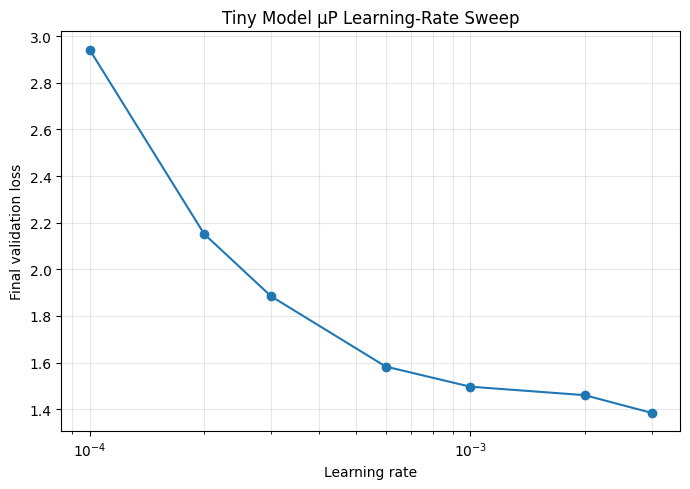

Saved plot: /content/drive/MyDrive/svg_gpt_scaling/notebook3_mup_scaling/plots/lr_sweep_tiny_mup_real.png
Best µP LR: 0.003


In [13]:
mode_suffix = "sanity" if SANITY_MODE else "real"

plt.figure(figsize=(7, 5))
plt.plot(df_mup_lr_sweep["base_learning_rate"], df_mup_lr_sweep["final_val_loss"], marker="o")
plt.xscale("log")
plt.xlabel("Learning rate")
plt.ylabel("Final validation loss")
plt.title("Tiny Model µP Learning-Rate Sweep")
plt.grid(True, which="both", alpha=0.3)
plt.tight_layout()

lr_plot_path = PLOTS_DIR / f"lr_sweep_tiny_mup_{mode_suffix}.png"
plt.savefig(lr_plot_path, dpi=200)
plt.show()

print("Saved plot:", lr_plot_path)
print("Best µP LR:", BEST_MUP_LR)

## 11. Train All 5 µP Model Sizes

In real mode, each model is trained for exactly 1 epoch using the µP LR selected from the Tiny sweep.

In [14]:
def load_best_mup_lr():
    mode_suffix = "sanity" if SANITY_MODE else "real"
    best_lr_path = RESULTS_DIR / f"best_lr_mup_{mode_suffix}.json"

    if best_lr_path.exists():
        with best_lr_path.open("r", encoding="utf-8") as f:
            data = json.load(f)
        return float(data["best_lr"])

    if "BEST_MUP_LR" in globals():
        return float(BEST_MUP_LR)

    raise FileNotFoundError(f"Could not find {best_lr_path}. Run the µP LR sweep first.")


BEST_MUP_LR_FOR_SCALING = load_best_mup_lr()
print("Using best µP LR for all model sizes:", BEST_MUP_LR_FOR_SCALING)


def run_mup_scaling_study():
    if SANITY_MODE:
        max_steps = SANITY_MAX_STEPS
        eval_iters = SANITY_EVAL_ITERS
        eval_interval = 10
        mode_suffix = "sanity"
    else:
        max_steps = None
        eval_iters = EVAL_ITERS
        eval_interval = EVAL_INTERVAL
        mode_suffix = "real"

    all_results = []

    for cfg in MUP_MODEL_CONFIGS:
        run_name = f"mup_scaling_{mode_suffix}_{cfg.name.lower()}"
        summary_path = RESULTS_DIR / f"{run_name}_summary.json"

        if RESUME_IF_CHECKPOINT_EXISTS and summary_path.exists():
            print(f"Reusing existing µP scaling result for {cfg.name}: {summary_path}")
            with summary_path.open("r", encoding="utf-8") as f:
                metadata = json.load(f)
        else:
            metadata = train_one_mup_run(
                config=cfg,
                learning_rate=BEST_MUP_LR_FOR_SCALING,
                run_name=run_name,
                max_steps=max_steps,
                eval_interval=eval_interval,
                eval_iters=eval_iters,
                resume=False,
            )

        all_results.append(metadata)

    df_scaling = pd.DataFrame(all_results)
    scaling_csv_path = RESULTS_DIR / f"mup_scaling_results_{mode_suffix}.csv"
    df_scaling.to_csv(scaling_csv_path, index=False)

    print("Saved µP scaling results:", scaling_csv_path)
    display(df_scaling[[
        "model_name", "params", "final_train_loss", "final_val_loss",
        "best_val_loss", "total_elapsed_sec", "tokens_per_sec",
        "gpu_memory_gb", "max_steps", "tokens_seen"
    ]])

    return df_scaling


df_mup_scaling = run_mup_scaling_study()

Using best µP LR for all model sizes: 0.003
µP Run: mup_scaling_real_tiny
Model: Tiny
Learning rate: 0.003
Max steps: 5016
Steps per epoch: 5016
Tokens per step: 32768
Warmup iters: 150
Checkpoint dir: /content/drive/MyDrive/svg_gpt_scaling/notebook3_mup_scaling/checkpoints/mup_scaling_real_tiny


/tmp/ipykernel_5108/2817039995.py:124: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=(DEVICE == "cuda" and DTYPE == "float16"))


iter      0/5016 | train loss 8.3125 | global lr 2.00e-05 | tok/s 510,442
  eval | train 8.3125 | val 8.3125 | best val 8.3125 | gpu 0.94 GB
iter     50/5016 | train loss 4.5645 | global lr 1.02e-03 | tok/s 436,320
iter    100/5016 | train loss 2.8175 | global lr 2.02e-03 | tok/s 512,324
iter    150/5016 | train loss 2.1907 | global lr 3.00e-03 | tok/s 543,041
iter    200/5016 | train loss 1.9553 | global lr 3.00e-03 | tok/s 559,027
iter    250/5016 | train loss 1.7719 | global lr 3.00e-03 | tok/s 570,006
iter    300/5016 | train loss 1.7391 | global lr 2.99e-03 | tok/s 577,448
iter    350/5016 | train loss 1.7240 | global lr 2.99e-03 | tok/s 582,466
iter    400/5016 | train loss 1.6537 | global lr 2.98e-03 | tok/s 585,198
iter    450/5016 | train loss 1.5723 | global lr 2.97e-03 | tok/s 588,525
iter    500/5016 | train loss 1.5959 | global lr 2.97e-03 | tok/s 591,062
  eval | train 1.5452 | val 1.5637 | best val 1.5637 | gpu 0.95 GB
iter    550/5016 | train loss 1.5784 | global lr 2.9

,model_name,params,final_train_loss,final_val_loss,best_val_loss,total_elapsed_sec,tokens_per_sec,gpu_memory_gb,max_steps,tokens_seen
0,Tiny,1907456,0.931006,0.952466,0.947877,280.839569,585260.434670,0.949877,5016,164364288
1,Small,4340736,0.816816,0.839726,0.836315,398.822277,412124.140372,1.641756,5016,164364288
2,Medium,13989888,0.786424,0.824152,0.818299,445.701535,368776.580312,2.133764,5016,164364288
3,Large,35981312,0.782735,0.795803,0.784872,969.682701,169503.166151,4.323339,5016,164364288
4,XL,91740672,0.811317,0.829749,0.822870,1734.061587,94785.726900,7.908979,5016,164364288


## 12. Plot µP Training Curves

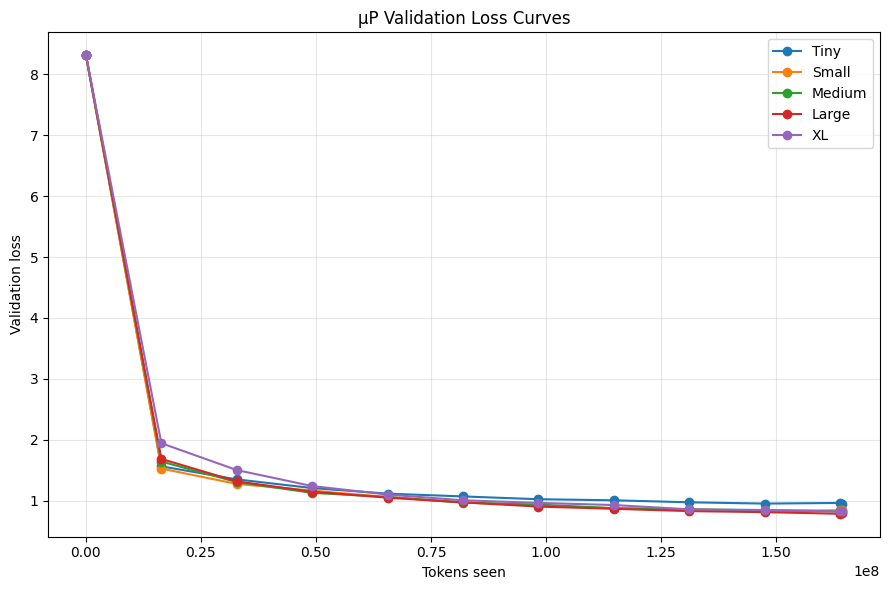

Saved plot: /content/drive/MyDrive/svg_gpt_scaling/notebook3_mup_scaling/plots/mup_training_curves_real.png


In [15]:
mode_suffix = "sanity" if SANITY_MODE else "real"

plt.figure(figsize=(9, 6))

for cfg in MUP_MODEL_CONFIGS:
    run_name = f"mup_scaling_{mode_suffix}_{cfg.name.lower()}"
    log_path = LOGS_DIR / f"{run_name}.csv"

    if not log_path.exists():
        print("Missing log:", log_path)
        continue

    df_log = pd.read_csv(log_path)
    plt.plot(df_log["tokens_seen"], df_log["val_loss"], marker="o", label=cfg.name)

plt.xlabel("Tokens seen")
plt.ylabel("Validation loss")
plt.title("µP Validation Loss Curves")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()

curves_path = PLOTS_DIR / f"mup_training_curves_{mode_suffix}.png"
plt.savefig(curves_path, dpi=200)
plt.show()

print("Saved plot:", curves_path)

## 13. Fit µP Scaling Law

We fit:

$$
L = aN^{-\alpha} + c
$$

In [16]:
def scaling_law(N, a, alpha, c):
    return a * (N ** (-alpha)) + c


def fit_scaling_law(df: pd.DataFrame, loss_col: str = "final_val_loss"):
    x = df["params"].astype(float).values
    y = df[loss_col].astype(float).values

    p0 = [max(y) - min(y), 0.05, min(y) * 0.9]
    bounds = ([0.0, 0.0, 0.0], [1000.0, 5.0, max(y)])

    popt, pcov = curve_fit(
        scaling_law,
        x,
        y,
        p0=p0,
        bounds=bounds,
        maxfev=10000,
    )

    a, alpha, c = popt
    y_pred = scaling_law(x, *popt)
    residuals = y - y_pred

    ss_res = np.sum(residuals ** 2)
    ss_tot = np.sum((y - np.mean(y)) ** 2)
    r2 = 1 - ss_res / ss_tot if ss_tot > 0 else float("nan")

    return {
        "a": float(a),
        "alpha": float(alpha),
        "c": float(c),
        "r2": float(r2),
        "covariance": pcov.tolist(),
        "x": x.tolist(),
        "y": y.tolist(),
        "y_pred": y_pred.tolist(),
        "residuals": residuals.tolist(),
    }


mup_fit_result = fit_scaling_law(df_mup_scaling, loss_col="final_val_loss")

mup_fit_path = RESULTS_DIR / f"mup_scaling_law_fit_{mode_suffix}.json"
with mup_fit_path.open("w", encoding="utf-8") as f:
    json.dump(mup_fit_result, f, indent=2)

print("µP scaling law fit:")
print(json.dumps({k: v for k, v in mup_fit_result.items() if k not in ["x", "y", "y_pred", "covariance", "residuals"]}, indent=2))
print("Saved µP fit:", mup_fit_path)

µP scaling law fit:
{
  "a": 999.9999999999999,
  "alpha": 0.6116495538335528,
  "c": 0.7861487470625664,
  "r2": 0.8116367896360249
}
Saved µP fit: /content/drive/MyDrive/svg_gpt_scaling/notebook3_mup_scaling/results/mup_scaling_law_fit_real.json


## 14. Load Standard Part 2 Results

Now we load Notebook 2 results so we can compare standard parameterization vs µP.

In [17]:
mode_suffix = "sanity" if SANITY_MODE else "real"

standard_results_path = NOTEBOOK2_DIR / "results" / f"standard_scaling_results_{mode_suffix}.csv"
standard_fit_path = NOTEBOOK2_DIR / "results" / f"standard_scaling_law_fit_{mode_suffix}.json"
standard_lr_sweep_path = NOTEBOOK2_DIR / "results" / f"lr_sweep_tiny_standard_{mode_suffix}.csv"

if not standard_results_path.exists():
    standard_results_path = NOTEBOOK2_DIR / "results" / "standard_scaling_results_real.csv"
    standard_fit_path = NOTEBOOK2_DIR / "results" / "standard_scaling_law_fit_real.json"
    standard_lr_sweep_path = NOTEBOOK2_DIR / "results" / "lr_sweep_tiny_standard_real.csv"

if not standard_results_path.exists():
    raise FileNotFoundError(f"Could not find standard Part 2 results: {standard_results_path}")

df_standard_scaling = pd.read_csv(standard_results_path)

if standard_fit_path.exists():
    with standard_fit_path.open("r", encoding="utf-8") as f:
        standard_fit_result = json.load(f)
else:
    standard_fit_result = fit_scaling_law(df_standard_scaling, loss_col="final_val_loss")

if standard_lr_sweep_path.exists():
    df_standard_lr_sweep = pd.read_csv(standard_lr_sweep_path)
else:
    df_standard_lr_sweep = None

print("Loaded standard results:", standard_results_path)
display(df_standard_scaling[[
    "model_name", "params", "final_val_loss", "best_val_loss",
    "tokens_per_sec", "gpu_memory_gb"
]])

print("Standard fit:")
print(json.dumps({k: v for k, v in standard_fit_result.items() if k in ["a", "alpha", "c", "r2"]}, indent=2))

Loaded standard results: /content/drive/MyDrive/svg_gpt_scaling/notebook2_standard_scaling/results/standard_scaling_results_real.csv


,model_name,params,final_val_loss,best_val_loss,tokens_per_sec,gpu_memory_gb
0,Tiny,1383168,0.911614,0.876584,754118.408678,0.562698
1,Small,3554304,0.801394,0.792083,537023.168015,0.779127
2,Medium,12417024,0.773271,0.754734,533068.097540,1.262346
3,Large,33884160,0.767520,0.747741,333859.632520,2.407393
4,XL,88594944,2.684681,1.420349,196062.971891,4.479008


Standard fit:
{
  "a": 2.2393843305811711e-13,
  "alpha": 5.628829028103905e-08,
  "c": 1.1876963405726477,
  "r2": -2.220446049250313e-16
}


## 15. Compare Standard vs µP Scaling Curves

This plot is required for Part 3.

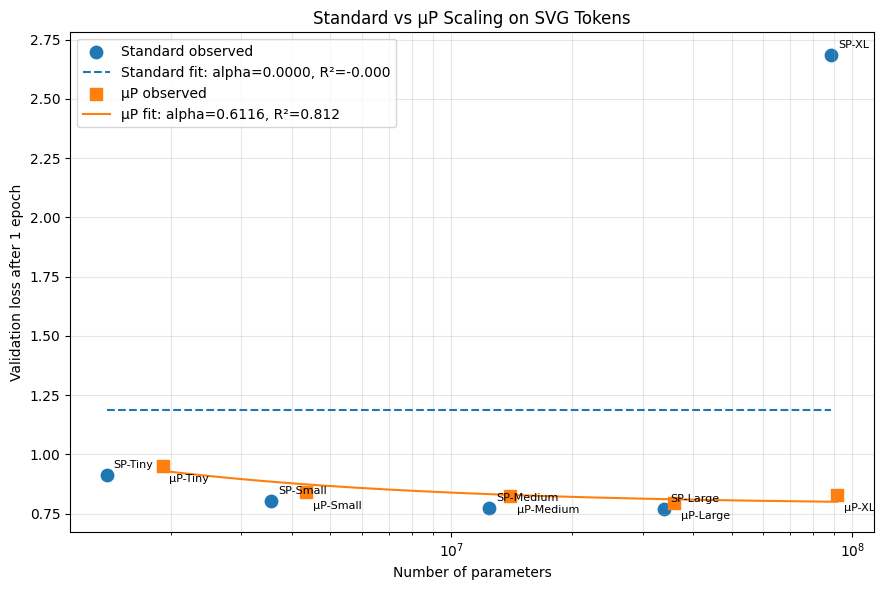

Saved comparison plot: /content/drive/MyDrive/svg_gpt_scaling/notebook3_mup_scaling/plots/standard_vs_mup_scaling_real.png


In [18]:
plt.figure(figsize=(9, 6))

x_std = df_standard_scaling["params"].astype(float).values
y_std = df_standard_scaling["final_val_loss"].astype(float).values
x_std_fit = np.logspace(np.log10(x_std.min()), np.log10(x_std.max()), 200)
y_std_fit = scaling_law(
    x_std_fit,
    standard_fit_result["a"],
    standard_fit_result["alpha"],
    standard_fit_result["c"]
)

plt.scatter(x_std, y_std, s=80, marker="o", label="Standard observed")
plt.plot(
    x_std_fit,
    y_std_fit,
    linestyle="--",
    label=f"Standard fit: alpha={standard_fit_result['alpha']:.4f}, R²={standard_fit_result['r2']:.3f}"
)

for _, row in df_standard_scaling.iterrows():
    plt.annotate(
        "SP-" + str(row["model_name"]),
        (row["params"], row["final_val_loss"]),
        textcoords="offset points",
        xytext=(5, 5),
        fontsize=8,
    )

x_mup = df_mup_scaling["params"].astype(float).values
y_mup = df_mup_scaling["final_val_loss"].astype(float).values
x_mup_fit = np.logspace(np.log10(x_mup.min()), np.log10(x_mup.max()), 200)
y_mup_fit = scaling_law(
    x_mup_fit,
    mup_fit_result["a"],
    mup_fit_result["alpha"],
    mup_fit_result["c"]
)

plt.scatter(x_mup, y_mup, s=80, marker="s", label="µP observed")
plt.plot(
    x_mup_fit,
    y_mup_fit,
    label=f"µP fit: alpha={mup_fit_result['alpha']:.4f}, R²={mup_fit_result['r2']:.3f}"
)

for _, row in df_mup_scaling.iterrows():
    plt.annotate(
        "µP-" + str(row["model_name"]),
        (row["params"], row["final_val_loss"]),
        textcoords="offset points",
        xytext=(5, -12),
        fontsize=8,
    )

plt.xscale("log")
plt.xlabel("Number of parameters")
plt.ylabel("Validation loss after 1 epoch")
plt.title("Standard vs µP Scaling on SVG Tokens")
plt.legend()
plt.grid(True, which="both", alpha=0.3)
plt.tight_layout()

comparison_plot_path = PLOTS_DIR / f"standard_vs_mup_scaling_{mode_suffix}.png"
plt.savefig(comparison_plot_path, dpi=200)
plt.show()

print("Saved comparison plot:", comparison_plot_path)

## 16. Compare Standard vs µP Learning-Rate Sweeps

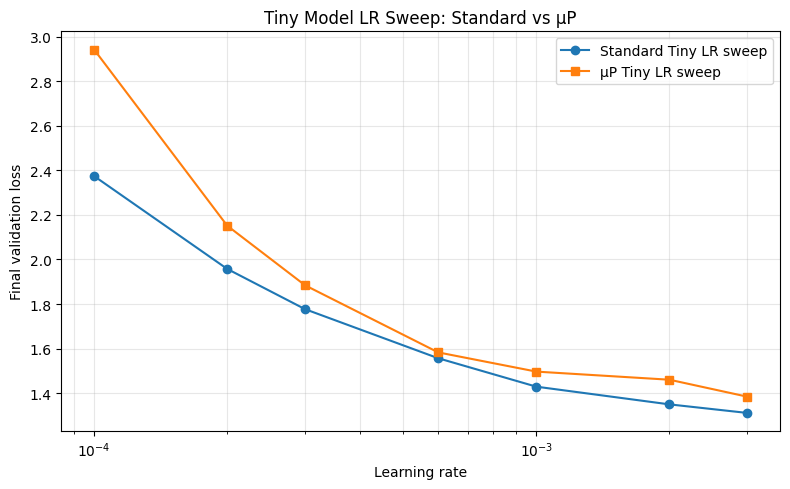

Saved LR comparison plot: /content/drive/MyDrive/svg_gpt_scaling/notebook3_mup_scaling/plots/standard_vs_mup_lr_sweep_real.png


In [19]:
plt.figure(figsize=(8, 5))

if df_standard_lr_sweep is not None:
    plt.plot(
        df_standard_lr_sweep["base_learning_rate"],
        df_standard_lr_sweep["final_val_loss"],
        marker="o",
        label="Standard Tiny LR sweep",
    )
else:
    print("Standard LR sweep CSV missing; plotting only µP.")

plt.plot(
    df_mup_lr_sweep["base_learning_rate"],
    df_mup_lr_sweep["final_val_loss"],
    marker="s",
    label="µP Tiny LR sweep",
)

plt.xscale("log")
plt.xlabel("Learning rate")
plt.ylabel("Final validation loss")
plt.title("Tiny Model LR Sweep: Standard vs µP")
plt.legend()
plt.grid(True, which="both", alpha=0.3)
plt.tight_layout()

lr_comparison_plot_path = PLOTS_DIR / f"standard_vs_mup_lr_sweep_{mode_suffix}.png"
plt.savefig(lr_comparison_plot_path, dpi=200)
plt.show()

print("Saved LR comparison plot:", lr_comparison_plot_path)

## 17. Create Comparison Table

In [20]:
df_sp = df_standard_scaling.copy()
df_sp["parameterization"] = "Standard"

df_mp = df_mup_scaling.copy()
df_mp["parameterization"] = "µP"

common_cols = [
    "parameterization",
    "model_name",
    "params",
    "final_train_loss",
    "final_val_loss",
    "best_val_loss",
    "total_elapsed_sec",
    "tokens_per_sec",
    "gpu_memory_gb",
    "max_steps",
    "tokens_seen",
]

df_compare = pd.concat([df_sp[common_cols], df_mp[common_cols]], ignore_index=True)
df_compare["params_millions"] = df_compare["params"] / 1e6
df_compare["wall_clock_hours"] = df_compare["total_elapsed_sec"] / 3600

display(df_compare)

comparison_table_path = RESULTS_DIR / f"standard_vs_mup_comparison_table_{mode_suffix}.csv"
df_compare.to_csv(comparison_table_path, index=False)

fit_summary = {
    "standard": {
        "a": standard_fit_result["a"],
        "alpha": standard_fit_result["alpha"],
        "c": standard_fit_result["c"],
        "r2": standard_fit_result["r2"],
    },
    "mup": {
        "a": mup_fit_result["a"],
        "alpha": mup_fit_result["alpha"],
        "c": mup_fit_result["c"],
        "r2": mup_fit_result["r2"],
    },
}

fit_summary_path = RESULTS_DIR / f"standard_vs_mup_fit_summary_{mode_suffix}.json"
with fit_summary_path.open("w", encoding="utf-8") as f:
    json.dump(fit_summary, f, indent=2)

print("Saved comparison table:", comparison_table_path)
print("Saved fit summary:", fit_summary_path)
print(json.dumps(fit_summary, indent=2))

,parameterization,model_name,params,final_train_loss,final_val_loss,best_val_loss,total_elapsed_sec,tokens_per_sec,gpu_memory_gb,max_steps,tokens_seen,params_millions,wall_clock_hours
0,Standard,Tiny,1383168,0.890887,0.911614,0.876584,217.955544,754118.408678,0.562698,5016,164364288,1.383168,0.060543
1,Standard,Small,3554304,0.786774,0.801394,0.792083,306.065544,537023.168015,0.779127,5016,164364288,3.554304,0.085018
2,Standard,Medium,12417024,0.738939,0.773271,0.754734,308.336381,533068.097540,1.262346,5016,164364288,12.417024,0.085649
3,Standard,Large,33884160,0.740568,0.767520,0.747741,492.315548,333859.632520,2.407393,5016,164364288,33.884160,0.136754
4,Standard,XL,88594944,2.639022,2.684681,1.420349,838.323965,196062.971891,4.479008,5016,164364288,88.594944,0.232868
5,µP,Tiny,1907456,0.931006,0.952466,0.947877,280.839569,585260.434670,0.949877,5016,164364288,1.907456,0.078011
6,µP,Small,4340736,0.816816,0.839726,0.836315,398.822277,412124.140372,1.641756,5016,164364288,4.340736,0.110784
7,µP,Medium,13989888,0.786424,0.824152,0.818299,445.701535,368776.580312,2.133764,5016,164364288,13.989888,0.123806
8,µP,Large,35981312,0.782735,0.795803,0.784872,969.682701,169503.166151,4.323339,5016,164364288,35.981312,0.269356
9,µP,XL,91740672,0.811317,0.829749,0.822870,1734.061587,94785.726900,7.908979,5016,164364288,91.740672,0.481684


Saved comparison table: /content/drive/MyDrive/svg_gpt_scaling/notebook3_mup_scaling/results/standard_vs_mup_comparison_table_real.csv
Saved fit summary: /content/drive/MyDrive/svg_gpt_scaling/notebook3_mup_scaling/results/standard_vs_mup_fit_summary_real.json
{
  "standard": {
    "a": 2.2393843305811711e-13,
    "alpha": 5.628829028103905e-08,
    "c": 1.1876963405726477,
    "r2": -2.220446049250313e-16
  },
  "mup": {
    "a": 999.9999999999999,
    "alpha": 0.6116495538335528,
    "c": 0.7861487470625664,
    "r2": 0.8116367896360249
  }
}


## 18. Scaling-Law Extrapolation

The project asks us to use the better scaling law from Parts 2–3 and predict validation loss for a model with **10× more parameters than the largest trained model**.

We choose the better fit by default using higher `R²`. If the plots show a clear reason to override this, explain the choice in the report.

In [21]:
def bootstrap_extrapolation(df: pd.DataFrame, n_bootstrap: int = 2000, random_seed: int = 42):
    rng = np.random.default_rng(random_seed)

    x = df["params"].astype(float).values
    y = df["final_val_loss"].astype(float).values

    largest_params = float(x.max())
    target_params = 10.0 * largest_params

    fit = fit_scaling_law(df, loss_col="final_val_loss")
    point_pred = float(scaling_law(target_params, fit["a"], fit["alpha"], fit["c"]))

    preds = []
    failed = 0

    n = len(df)
    for _ in range(n_bootstrap):
        idx = rng.integers(0, n, size=n)

        if len(set(idx.tolist())) < 3:
            failed += 1
            continue

        df_b = df.iloc[idx].reset_index(drop=True)

        try:
            fit_b = fit_scaling_law(df_b, loss_col="final_val_loss")
            pred_b = float(scaling_law(target_params, fit_b["a"], fit_b["alpha"], fit_b["c"]))
            if np.isfinite(pred_b):
                preds.append(pred_b)
        except Exception:
            failed += 1

    preds = np.array(preds, dtype=float)

    if len(preds) == 0:
        ci_low = float("nan")
        ci_high = float("nan")
        pred_mean = float("nan")
    else:
        ci_low = float(np.percentile(preds, 2.5))
        ci_high = float(np.percentile(preds, 97.5))
        pred_mean = float(np.mean(preds))

    return {
        "largest_trained_params": largest_params,
        "target_params_10x_largest": target_params,
        "point_prediction": point_pred,
        "bootstrap_mean_prediction": pred_mean,
        "ci_95_low": ci_low,
        "ci_95_high": ci_high,
        "num_bootstrap_success": int(len(preds)),
        "num_bootstrap_failed": int(failed),
        "fit": fit,
    }


standard_r2 = float(standard_fit_result.get("r2", float("-inf")))
mup_r2 = float(mup_fit_result.get("r2", float("-inf")))

if mup_r2 >= standard_r2:
    best_name = "mup"
    best_df = df_mup_scaling.copy()
else:
    best_name = "standard"
    best_df = df_standard_scaling.copy()

print("Chosen extrapolation source:", best_name)
print("Standard R²:", standard_r2)
print("µP R²:", mup_r2)

extrap_result = bootstrap_extrapolation(best_df, n_bootstrap=2000, random_seed=RANDOM_SEED)
extrap_result["chosen_source"] = best_name

extrap_path = RESULTS_DIR / f"scaling_extrapolation_10x_{mode_suffix}.json"
with extrap_path.open("w", encoding="utf-8") as f:
    json.dump(extrap_result, f, indent=2)

print("Extrapolation result:")
print(json.dumps({
    "chosen_source": extrap_result["chosen_source"],
    "largest_trained_params": extrap_result["largest_trained_params"],
    "target_params_10x_largest": extrap_result["target_params_10x_largest"],
    "point_prediction": extrap_result["point_prediction"],
    "bootstrap_mean_prediction": extrap_result["bootstrap_mean_prediction"],
    "ci_95_low": extrap_result["ci_95_low"],
    "ci_95_high": extrap_result["ci_95_high"],
    "num_bootstrap_success": extrap_result["num_bootstrap_success"],
    "num_bootstrap_failed": extrap_result["num_bootstrap_failed"],
}, indent=2))

print("Saved extrapolation:", extrap_path)

Chosen extrapolation source: mup
Standard R²: -2.220446049250313e-16
µP R²: 0.8116367896360249
Extrapolation result:
{
  "chosen_source": "mup",
  "largest_trained_params": 91740672.0,
  "target_params_10x_largest": 917406720.0,
  "point_prediction": 0.7894452464718295,
  "bootstrap_mean_prediction": 0.7879357647698715,
  "ci_95_low": 0.7356226715942252,
  "ci_95_high": 0.8254551613084381,
  "num_bootstrap_success": 1814,
  "num_bootstrap_failed": 186
}
Saved extrapolation: /content/drive/MyDrive/svg_gpt_scaling/notebook3_mup_scaling/results/scaling_extrapolation_10x_real.json


## 19. Plot Extrapolation

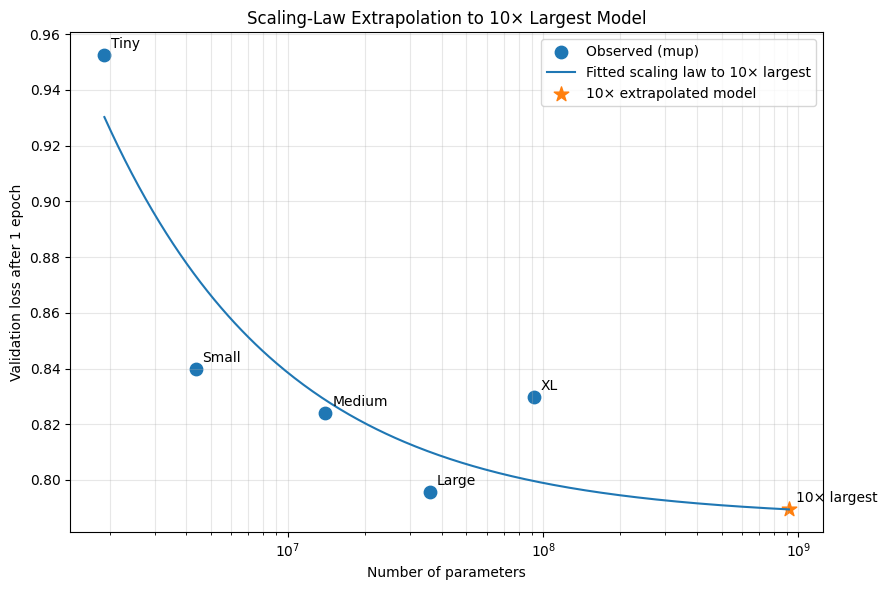

Saved extrapolation plot: /content/drive/MyDrive/svg_gpt_scaling/notebook3_mup_scaling/plots/scaling_extrapolation_10x_real.png


In [22]:
best_df = df_mup_scaling if extrap_result["chosen_source"] == "mup" else df_standard_scaling
fit = extrap_result["fit"]

x = best_df["params"].astype(float).values
y = best_df["final_val_loss"].astype(float).values

target_params = extrap_result["target_params_10x_largest"]
point_prediction = extrap_result["point_prediction"]

x_fit = np.logspace(np.log10(x.min()), np.log10(target_params), 300)
y_fit = scaling_law(x_fit, fit["a"], fit["alpha"], fit["c"])

plt.figure(figsize=(9, 6))
plt.scatter(x, y, s=80, label=f"Observed ({extrap_result['chosen_source']})")
plt.plot(x_fit, y_fit, label="Fitted scaling law to 10× largest")

plt.scatter(
    [target_params],
    [point_prediction],
    s=120,
    marker="*",
    label="10× extrapolated model",
)

for _, row in best_df.iterrows():
    plt.annotate(
        str(row["model_name"]),
        (row["params"], row["final_val_loss"]),
        textcoords="offset points",
        xytext=(5, 5),
    )

plt.annotate(
    "10× largest",
    (target_params, point_prediction),
    textcoords="offset points",
    xytext=(5, 5),
)

plt.xscale("log")
plt.xlabel("Number of parameters")
plt.ylabel("Validation loss after 1 epoch")
plt.title("Scaling-Law Extrapolation to 10× Largest Model")
plt.legend()
plt.grid(True, which="both", alpha=0.3)
plt.tight_layout()

extrap_plot_path = PLOTS_DIR / f"scaling_extrapolation_10x_{mode_suffix}.png"
plt.savefig(extrap_plot_path, dpi=200)
plt.show()

print("Saved extrapolation plot:", extrap_plot_path)

## 20. Part 3 summary

In [25]:
report_notes_lines = [
    "Part 3 Summary - muP Scaling and Extrapolation",
    "",
    "muP learning-rate sweep:",
    f"- Learning rates tested: {MUP_LR_SWEEP_VALUES}",
    f"- Best muP learning rate selected by final validation loss: {BEST_MUP_LR_FOR_SCALING}",
    "",
    "Standard parameterization fit:",
    f"- alpha = {standard_fit_result['alpha']:.6f}",
    f"- c = {standard_fit_result['c']:.6f}",
    f"- R^2 = {standard_fit_result['r2']:.6f}",
    "",
    "muP fit:",
    f"- alpha = {mup_fit_result['alpha']:.6f}",
    f"- c = {mup_fit_result['c']:.6f}",
    f"- R^2 = {mup_fit_result['r2']:.6f}",
    "",
    "Extrapolation:",
    f"- Chosen scaling law source: {extrap_result['chosen_source']}",
    f"- Largest trained model parameters: {extrap_result['largest_trained_params']:.0f}",
    f"- 10x target parameter count: {extrap_result['target_params_10x_largest']:.0f}",
    f"- Predicted validation loss: {extrap_result['point_prediction']:.6f}",
    f"- Bootstrap mean prediction: {extrap_result['bootstrap_mean_prediction']:.6f}",
    f"- Approximate 95% CI: [{extrap_result['ci_95_low']:.6f}, {extrap_result['ci_95_high']:.6f}]",
    "",
]

report_notes = "\n".join(report_notes_lines)

notes_path = RESULTS_DIR / f"part3_report_notes_{mode_suffix}.txt"
with notes_path.open("w", encoding="utf-8") as f:
    f.write(report_notes)

print(report_notes)
print("Saved report notes:", notes_path)

Part 3 Summary - muP Scaling and Extrapolation

muP learning-rate sweep:
- Learning rates tested: [0.0001, 0.0002, 0.0003, 0.0006, 0.001, 0.002, 0.003]
- Best muP learning rate selected by final validation loss: 0.003

Standard parameterization fit:
- alpha = 0.000000
- c = 1.187696
- R^2 = -0.000000

muP fit:
- alpha = 0.611650
- c = 0.786149
- R^2 = 0.811637

Extrapolation:
- Chosen scaling law source: mup
- Largest trained model parameters: 91740672
- 10x target parameter count: 917406720
- Predicted validation loss: 0.789445
- Bootstrap mean prediction: 0.787936
- Approximate 95% CI: [0.735623, 0.825455]

Saved report notes: /content/drive/MyDrive/svg_gpt_scaling/notebook3_mup_scaling/results/part3_report_notes_real.txt


In [24]:
print("Author: Naman Singh")

Author: Naman Singh


## 21. Part 3 Outcomes

After running in real mode, these files exist:

```text
MyDrive/
  svg_gpt_scaling/
    notebook3_mup_scaling/
      checkpoints/
        mup_scaling_real_tiny/final.pt
        mup_scaling_real_small/final.pt
        mup_scaling_real_medium/final.pt
        mup_scaling_real_large/final.pt
        mup_scaling_real_xl/final.pt

      logs/
        mup_scaling_real_tiny.csv
        mup_scaling_real_small.csv
        mup_scaling_real_medium.csv
        mup_scaling_real_large.csv
        mup_scaling_real_xl.csv

      results/
        lr_sweep_tiny_mup_real.csv
        best_lr_mup_real.json
        mup_scaling_results_real.csv
        mup_scaling_law_fit_real.json
        standard_vs_mup_comparison_table_real.csv
        standard_vs_mup_fit_summary_real.json
        scaling_extrapolation_10x_real.json
        part3_report_notes_real.txt

      plots/
        lr_sweep_tiny_mup_real.png
        mup_training_curves_real.png
        standard_vs_mup_scaling_real.png
        standard_vs_mup_lr_sweep_real.png
        scaling_extrapolation_10x_real.png
```